## 06. Reproduce the 2016 paper
**26 March 2025 by MiniUFO**

---
[TOC]

---
### 1. Introduction
Here we reproduce results from several papers on relative dispersion which used the same GLAD drifter dataset.  The first one is the second-order structure function, as well as its decompositions, shown by [Balwada et al. (2016)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016GL069405).

---

### 2. Calculation
#### 2.1 load the GLAD dataset

In [1]:
import numpy as np
import xarray as xr
import warnings
import sys
warnings.filterwarnings("ignore")
sys.path.append('../../../')
from xdispersion import RelativeDispersion

drifters = xr.open_dataset('../../../data/glad32.nc')

rd = RelativeDispersion(drifters, maxtlen=4*24*85, ragged=True, ID='traj',
                        xpos='longitude', uvel='ve', time='time', Rearth=6371.2,
                        ypos='latitude' , vvel='vn', coord='latlon')

pairs = rd.get_all_pairs()
print(pairs)

there are 43518 pairs of particles
<xarray.Dataset> Size: 3MB
Dimensions:   (pair: 43518, particle: 2)
Coordinates:
  * pair      (pair) int32 174kB 0 1 2 3 4 5 ... 43513 43514 43515 43516 43517
  * particle  (particle) int32 8B 0 1
Data variables:
    tlen      (pair) int32 174kB 1385 2965 3729 5641 ... 1405 1535 1405 1394
    stim      (pair) datetime64[ns] 348kB 2012-07-20T04:00:00 ... 2012-08-12T...
    r0        (pair) float32 174kB 29.19 39.47 54.57 ... 0.5697 212.1 211.3
    pID       (pair, particle) int32 348kB 0 1 0 2 0 3 ... 294 293 296 294 296
    xpos0     (pair, particle) float32 348kB -87.21 -87.5 ... -87.98 -87.76
    ypos0     (pair, particle) float32 348kB 28.55 28.6 28.54 ... 29.17 27.28
    idxI      (pair, particle) int32 348kB 10 1395 15 ... 1595639 1597033
    idxJ      (pair, particle) int32 348kB 7695 9080 9080 ... 1601488 1602882


#### 2.2 Calculate structure functions
All the separation-based measures can be calculated by a single call and we only pick up those related to 2nd-order velocity structure functions:

In [6]:
from xdispersion import rotational_divergent_components, gen_rbins

alpha = 1.2
rbins = gen_rbins(0.001, 1000, alpha)

# _, S2, S2L, S2T, _, _, _, _, _, _, _, _ = rd.r_based_measures_bak(pairs, alpha, rbins)
# S2r, S2d = rotational_divergent_components(S2L, S2T)

re = rd.r_based_measures(pairs, alpha, rbins)

#### 2.3 Plot the structure functions

Now we have the total structure functions S2, as well as its **longitudinal/transversal** components and **rotational/divergent** components.

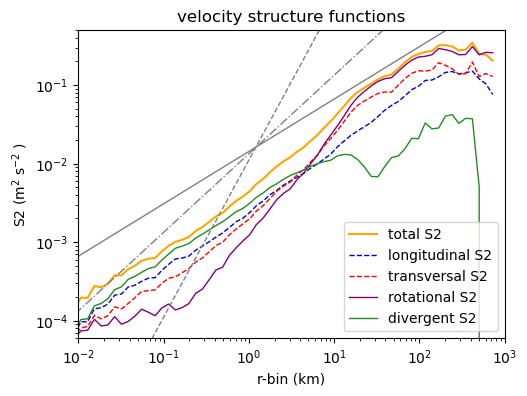

In [37]:
import matplotlib.pyplot as plt

m1 = S2.plot.line(xscale='log', yscale='log', figsize=(5.5,4), color='orange', lw=1.5, zorder=1, label='total S2')
m2 = S2L.plot(linestyle='--', color='mediumblue', lw=1, zorder=1, label='longitudinal S2')
m3 = S2T.plot(linestyle='--', color='r', lw=1, zorder=1, label='transversal S2')
m4 = S2r.plot(color='purple', lw=1, zorder=1, label='rotational S2')
m5 = S2d.plot(color='forestgreen', lw=1, zorder=1, label='divergent S2')
plt.plot(S2.rbin, S2.rbin**2/90, color='gray', lw=1, linestyle='--')
plt.plot(S2.rbin, S2.rbin/75, color='gray', lw=1, linestyle='-.')
plt.plot(S2.rbin, S2.rbin**(2/3)/70, color='gray', lw=1)
plt.legend([m1[0].get_label(), m2[0].get_label(), m3[0].get_label(),
            m4[0].get_label(), m5[0].get_label()], loc='lower right')
plt.xlim([1e-2, 1e3])
plt.ylim([6e-5, 5e-1])
plt.title('velocity structure functions')
plt.xlabel('r-bin (km)')
_ = plt.ylabel('S2 (m$^2$ s$^{-2}$ )')

### 3. Conclusions

This reproduced almost every aspect of Fig. 2a in [Balwada et al. (2016)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016GL069405).

### References:
- Balwada, D., J. H. LaCasce, and K. G. Speer, 2016: [Scale-dependent distribution of kinetic energy from surface drifters in the Gulf of Mexico](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016GL069405). *Geophys. Res. Lett.*, **43**, 10856-10863.